In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import math

plt.style.use('seaborn-v0_8') # I personally prefer seaborn for the graph style, but you may choose whichever you want.
params = {"ytick.color" : "black",
          "xtick.color" : "black",
          "axes.labelcolor" : "black",
          "axes.edgecolor" : "black",
          "text.usetex" : True,
          "font.family" : "serif",
          "font.serif" : ["Computer Modern Serif"]}
plt.rcParams.update(params)

output_dir = "/Users/russell/projects/stencil_research/fft_bench/plots"

In [18]:
sv_values = set()
for i in range(0, 14):
    for j in range(0, 9):
        for k in range(0, 6):
            for l in range(0, 5):
                for n in range(0, 4):
                    for m in range(0, 4):
                            v = 2**i * 3**j * 5**k * 7**l * 11**n * 13**m
                            if v > 1000 and v < 14050:
                                sv_values.add(v)
sv = sorted(sv_values)

In [19]:
warmup_iter = 2

results_dirs = [
    "/Users/russell/projects/stencil_research/fft_bench/results/expanse_3",
]

plan_data_sv = {
    "Estimate": {},
    "Measure": {},
    "MKL_OUT_OF_PLACE": {}
}

plan_data_bad = {
    "Estimate": {},
    "Measure": {},
    "MKL_OUT_OF_PLACE": {}
}

def load_results_file(path):
    with open(json_path, 'r') as json_file:
        data = json.load(json_file)
        plan_type = data["plan_type"]
        time = np.average(data["timings"][warmup_iter:])
        plan_size = data["plan_size"]
        if plan_size in sv_values:
            plan_data_sv[plan_type][plan_size] = time
        else:
            plan_data_bad[plan_type][plan_size] = time
        
for results_dir in results_dirs:  
    for file in sorted(os.listdir(results_dir)):
        json_path = f"{results_dir}/{file}"
        load_results_file(json_path)

In [20]:
plot_data = {}
for plan_type in plan_data_sv.keys():
    name = f"{plan_type} Ideal Size"
    plan_sizes = sorted(plan_data_sv[plan_type].keys())
    times = [plan_data_sv[plan_type][plan_size] for plan_size in plan_sizes]
    plot_data[name] = {}
    plot_data[name]["plan_sizes"] = plan_sizes
    plot_data[name]["times"] = times

for plan_type in plan_data_bad.keys():
    name = f"{plan_type} bad"
    plan_sizes = sorted(plan_data_bad[plan_type].keys())
    times = [plan_data_bad[plan_type][plan_size] for plan_size in plan_sizes]
    plot_data[name] = {}
    plot_data[name]["plan_sizes"] = plan_sizes
    plot_data[name]["times"] = times

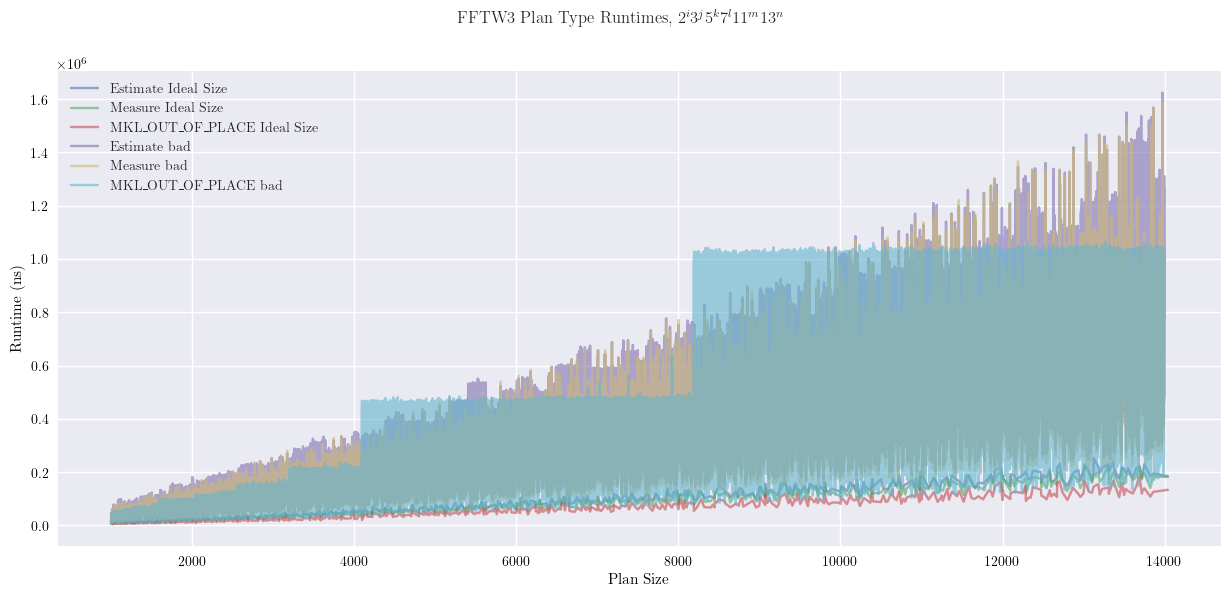

In [8]:
fig = plt.figure(figsize=(width, width * height_ratio))
n_rows = 1
n_cols = 1
width_ratios = [1.0]
height_ratios = [1.0]
gs1 = fig.add_gridspec(
    n_rows, n_cols,
    width_ratios = width_ratios, 
    height_ratios = height_ratios,
    wspace = 0.15,
    hspace = 0.15,
)
ax = fig.add_subplot(gs1[0, 0])


for plan_type in plot_data.keys():
    ax.plot(plot_data[plan_type]["plan_sizes"], plot_data[plan_type]["times"], label=plan_type, alpha=0.6)

ax.legend()
ax.set_ylabel("Runtime (ns)")
ax.set_xlabel("Plan Size")
fig.suptitle("FFTW3 Plan Type Runtimes, $2^i 3^j 5^k 7^l 11^m 13^n$")
plt.savefig(f"{output_dir}/plan_type_runtimes_exp3.pdf")

In [14]:
sv_plan_sizes = []
sv_speedup = []
for plan_size in sorted(plan_data_sv["Estimate"].keys()):
    sv_plan_sizes.append(plan_size)
    est_time = plan_data_sv["Estimate"][plan_size]
    mes_time = plan_data_sv["Measure"][plan_size]
    sv_speedup.append(est_time / mes_time)

mkl_plan_sizes = []
mkl_speedup = []
for plan_size in sorted(plan_data_sv["Measure"].keys()):
    mkl_plan_sizes.append(plan_size)
    mes_time = plan_data_sv["Measure"][plan_size]
    mkl_time = plan_data_sv["MKL_OUT_OF_PLACE"][plan_size]
    mkl_speedup.append(mes_time / mkl_time)
    
bad_plan_sizes = []
bad_speedup = []
for plan_size in sorted(plan_data_bad["Estimate"].keys()):
    bad_plan_sizes.append(plan_size)
    est_time = plan_data_bad["Estimate"][plan_size]
    mes_time = plan_data_bad["Measure"][plan_size]
    bad_speedup.append(est_time / mes_time)

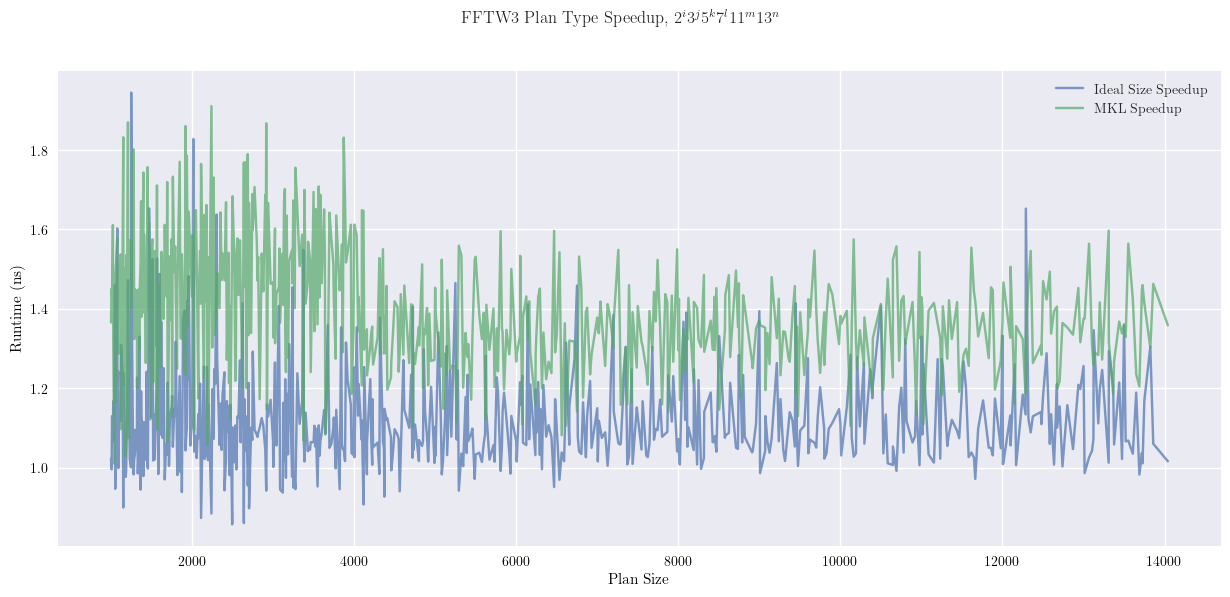

In [16]:
fig = plt.figure(figsize=(width, width * height_ratio))
n_rows = 1
n_cols = 1
width_ratios = [1.0]
height_ratios = [1.0]
gs1 = fig.add_gridspec(
    n_rows, n_cols,
    width_ratios = width_ratios, 
    height_ratios = height_ratios,
    wspace = 0.15,
    hspace = 0.15,
)
ax = fig.add_subplot(gs1[0, 0])

#ax.plot(bad_plan_sizes, bad_speedup, label="Bad Size Speedup", alpha=0.7)
ax.plot(sv_plan_sizes, sv_speedup, label="Ideal Size Speedup", alpha=0.7)
ax.plot(mkl_plan_sizes, mkl_speedup, label="MKL Speedup", alpha=0.7)

ax.legend()
ax.set_ylabel("Runtime (ns)")
ax.set_xlabel("Plan Size")
fig.suptitle("FFTW3 Plan Type Speedup, $2^i 3^j 5^k 7^l 11^m 13^n$")
plt.savefig(f"{output_dir}/plan_type_runtimes_exp3.pdf")

In [1]:
# Measure speedup,
# For each plansize in measure
# find next largest 

next_plan_sizes = []
next_speedup = []

def find_next_sv(plan_size):
    i = plan_size
    while i < 14050:
        if i in sv_values:
             return plan_data_sv["Measure"][i]
        i += 1

for plan_size in sorted(plan_data_bad["Measure"].keys()):
    next_plan_sizes.append(plan_size)
    mes_time = plan_data_bad["Measure"][plan_size]
    next_size = find_next_sv(plan_size)
    next_time = plan_data_sv["Measure"][next_size]
    next_speedup.append(next_time / mes_time)
        

NameError: name 'plan_data_bad' is not defined